In [ ]:
import pandas as pd
import os
import re
import nltk
import numpy as np
import math
from pymystem3 import Mystem
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfTransformer

mystem = Mystem()

## 1. Подготовка данных ##

#### 1.2. Подготовка датафрейма ####

In [ ]:
def cleaner(dataframe, exclude=None):
    if exclude is None:
        exclude = []
    for col in dataframe.columns:
        if col in exclude:
            continue

        if dataframe[col].dtype == 'object':
            dataframe[col] = (dataframe[col]
                              .astype(str)
                              .str.replace(r'\s+', ' ', regex=True)
                              .str.replace('ё', 'е', regex=False)
                              .str.replace('Ё', 'е', regex=False)
                              .str.strip()
                              .str.lower())
            dataframe[col] = dataframe[col].replace('nan', np.nan)

    return dataframe



## 2. Базовый датафрейм c нужными показателями для дальнейшей обработки ##

#### 2.1. Формирование датафрейма для дальнейшей работы ####

Первичные данные после эксперимента необходимо обработать так, чтобы это было похоже на стандартную словарную статью в ассоциативных словарях. Для этого, в первую очередь, прохожу по каждому стимулу, нахожу совпадающие ассоциации и присваиваю им показатели абсолютной частоты (в рамках ассоциативного поля к каждому стимулу по-отдельности).

In [ ]:
df_frequencies = []

for stimulus in df.columns:
    associations = df[stimulus].dropna()
    value_counts = associations.value_counts()

    freq_df = pd.DataFrame({
        'стимул': stimulus,
        'ассоциация': value_counts.index,
        'частота': value_counts.values
    })
    df_frequencies.append(freq_df)

df_frequencies = pd.concat(df_frequencies, ignore_index=True)



display(df_frequencies.head(10))

,стимул,ассоциация,частота
0,глаз,зрение,69
1,глаз,зрачок,29
2,глаз,очки,27
3,глаз,око,26
4,глаз,голубой,24
5,глаз,алмаз,20
6,глаз,видеть,15
7,глаз,зеленый,14
8,глаз,нос,14
9,глаз,яблоко,13


#### 2.2. Лемматизация и POS-тегинг ####

Для анализа всей сформированной ассоциативно-вербальной сети производим лемматизацию ассоциаций. Этот шаг потом позволит рассмотреть повторяющиеся ассоциации во всей сети, выявить самые частотные. Частеречная разметка необходима, чтобы проводить дальнейшие исследования ассоциативных полей с учетом их грамматических особенностей.

In [ ]:
mystem = Mystem(disambiguation=False)

In [ ]:
def lemmatize_and_tag_mystem_full(text):
    if pd.isna(text) or str(text).strip() == '':
        return "", "", ""

    analysis = mystem.analyze(str(text))
    lemmas_list, pos_tags_list, grammemes_list = [], [], []

    for item in analysis:
        if 'analysis' in item and item['analysis']:
            lemmas_list.append(item['analysis'][0]['lex'])

            word_pos_variants = []
            word_gram_variants = []

            #  все варианты разбора для отображения омонимии
            for variant in item['analysis']:
                gr = variant['gr']
                pos = gr.split(',')[0].split('=')[0]

                if pos not in word_pos_variants:
                    word_pos_variants.append(pos)
                if gr not in word_gram_variants:
                    word_gram_variants.append(gr)

            pos_tags_list.append(' / '.join(word_pos_variants))
            grammemes_list.append(' / '.join(word_gram_variants))

    return ' '.join(lemmas_list), ' + '.join(pos_tags_list), ' + '.join(grammemes_list)

# 1. Разметка ассоциаций

df_frequencies[['лемма', 'часть речи ассоциации', 'граммемы ассоциации']] = df_frequencies['ассоциация'].apply(
    lambda x: pd.Series(lemmatize_and_tag_mystem_full(x))
)

# 2. Разметка стимулов (через уникальные значения)
print("Разметка стимулов...")
stimuli_unique = pd.DataFrame({'стимул': df_frequencies['стимул'].unique()})

def process_stim(text):
    l, p, g = lemmatize_and_tag_mystem_full(text)
    # только первое слово для характеристик стимула
    return pd.Series([p.split(' + ')[0], g.split(' + ')[0]])

stimuli_unique[['часть речи стимула', 'граммемы стимула']] = stimuli_unique['стимул'].apply(process_stim)

# 3.
df_frequencies = df_frequencies.merge(stimuli_unique, on='стимул', how='left')

# 4.
order = [
    'стимул', 'часть речи стимула', 'граммемы стимула',
    'ассоциация', 'частота',
    'лемма', 'часть речи ассоциации', 'граммемы ассоциации'
]


df_frequencies = df_frequencies[[c for c in order if c in df_frequencies.columns]]

display(df_frequencies.head(10))

Разметка ассоциаций...
Разметка стимулов...


,стимул,часть речи стимула,граммемы стимула,ассоциация,частота,лемма,часть речи ассоциации,граммемы ассоциации
0,глаз,S,"S,муж,неод=(вин,ед|род,мн|им,ед)",зрение,69,зрение,S,"S,сред,неод=(вин,ед|им,ед)"
1,глаз,S,"S,муж,неод=(вин,ед|род,мн|им,ед)",зрачок,29,зрачок,S,"S,муж,неод=(вин,ед|им,ед)"
2,глаз,S,"S,муж,неод=(вин,ед|род,мн|им,ед)",очки,27,очки,S,"S,мн,неод=(вин|им) / S,сред,неод=(вин,мн|им,мн)"
3,глаз,S,"S,муж,неод=(вин,ед|род,мн|им,ед)",око,26,око,S,"S,сред,неод=(вин,ед|им,ед)"
4,глаз,S,"S,муж,неод=(вин,ед|род,мн|им,ед)",голубой,24,голубой,A / S,"A=(вин,ед,полн,муж,неод|им,ед,полн,муж|пр,ед,п..."
5,глаз,S,"S,муж,неод=(вин,ед|род,мн|им,ед)",алмаз,20,алмаз,S,"S,муж,неод=(вин,ед|им,ед) / S,имя,муж,од=им,ед"
6,глаз,S,"S,муж,неод=(вин,ед|род,мн|им,ед)",видеть,15,видеть,V,"V,несов,пе=инф"
7,глаз,S,"S,муж,неод=(вин,ед|род,мн|им,ед)",зеленый,14,зеленый,A,"A=(вин,ед,полн,муж,неод|им,ед,полн,муж)"
8,глаз,S,"S,муж,неод=(вин,ед|род,мн|им,ед)",нос,14,нос,S,"S,муж,неод=(вин,ед|им,ед)"
9,глаз,S,"S,муж,неод=(вин,ед|род,мн|им,ед)",орган,13,орган,S,"S,муж,неод=(вин,ед|им,ед)"


In [ ]:
df_frequencies = cleaner(df_frequencies, exclude=['часть речи стимула', 'часть речи ассоциации', 'граммемы стимула', 'граммемы ассоциации'])

## 3. Обработка лемматизированных ассоциаций ##

#### 3.1. Частоты лемм ####

Пересчитываем частоты лемматизированных ассоциаций: учитываем частоту каждой словоформы.

In [ ]:
df_lemmas = df_frequencies.groupby(['стимул', 'лемма'], as_index=False)['частота'].sum()

df_lemmas = df_lemmas.sort_values(['стимул', 'частота'], ascending=[True, False])
display(df_lemmas.head().style.hide(axis='index'))

стимул,лемма,частота
автомобиль,машина,63
автомобиль,колесо,24
автомобиль,дорога,22
автомобиль,руль,19
автомобиль,транспорт,19


In [ ]:
df_lemmas = cleaner (df_lemmas)

 #### 3.2. Пересечения лемм ####

Смотрим, какие леммы приводились к разным стимулам. Часто повторяющиеся леммы-ассоциации - это ядро ассоциативно-вербальной сети.

In [ ]:

clean_lemmas = df_lemmas[
    (df_lemmas['лемма'].str.strip() != '') &
    (df_lemmas['лемма'].notna())
].copy()

# Поиск совпадающих лемм у разных стимулов
shared_lemmas = clean_lemmas.groupby('лемма')['стимул'].agg( #группировка совпадающих лемм
    Количество_стимулов='nunique',
    Список_стимулов=lambda x: ', '.join(sorted(x.unique()))
).reset_index()


shared_lemmas = shared_lemmas[shared_lemmas['Количество_стимулов'] > 1].sort_values('Количество_стимулов', ascending=False)
shared_lemmas.columns = ['лемма', 'количество стимулов', 'список стимулов']

display(shared_lemmas.head().style.hide(axis='index'))

In [ ]:
shared_lemmas = cleaner(shared_lemmas)

## 4. Статистика: подсчет базовых показателей для ассоциативного словаря, анализ частей речи, TF-IDF, лексическое разнообразие, сила связи ядерных ассоциаций ##

#### 4.1. Количественная характеристика стимулов ####

Для словарных статей ассоциативных словарей, как правило, приводятся следующие количественные показатели к каждому стимулу: а) всего ответов, б) количество различных ассоциаций, в) количество единичных ассоциаций; г) количество отказов.
Формула лексического разнообразию берется из трудов Ю.Н. Караулова, это общепринятая формула в подобных исследованиях.

In [ ]:

stats_list = []

for slovo, sub_df in df_frequencies.groupby('стимул'):
    total = sub_df['частота'].sum() # всего ответов
    refusals = sub_df[sub_df['ассоциация'] == 'not']['частота'].sum() # сколько отказов
    valid_rows = sub_df[sub_df['ассоциация'] != 'not'] # только ассоциации, без отказов
    distinct = len(valid_rows) # уникальные ассоциации (без отказов)
    singles = len(valid_rows[valid_rows['частота'] == 1]) # одиночные ассоциации

    stats_list.append({
        'стимул': slovo,
        'часть речи стимула': sub_df['часть речи стимула'].iloc[0],
        'всего': total,
        'различные ассоциации': distinct,
        'одиночные ассоциации': singles,
        'отказы': refusals,
        'лексическое разнообразие': round(distinct / total, 3) if total > 0 else 0 # по Караулову
    })

df_summary = pd.DataFrame(stats_list)

display(df_summary.sort_values('лексическое разнообразие', ascending=False).head().style.hide(axis='index'))



стимул,часть речи стимула,всего,различные ассоциации,одиночные ассоциации,отказы,лексическое разнообразие
система,S,498,282,218,0,0.566000
требование,S,494,275,209,0,0.557000
внимание,S,496,276,203,0,0.556000
география,S,496,274,207,0,0.552000
позиция,S,499,275,200,0,0.551000


#### 4.2. Статистика по частям речи ####

Далее необходимо сделать расчеты касательно частеречных характеристик ассоциаций. В ответах респондентов встречаются ассоциации более чем из одного слова, для таких слов мы проставляли теги частей речи через +, в этой статистики все "плюсовые" теги будем считать в одной группе. Проценты считаются только для слов, к которым при морфологическом анализе была указана часть речи.

In [ ]:

all_pos = [tag for tag in df2['часть речи ассоциации'].unique() if "+" not in str(tag) and tag != ""]

pos_data = []
for slovo, sub_df in df2.groupby('стимул'):
    meaningful = sub_df[sub_df['часть речи ассоциации'] != ""] #берем только, те у которых ч.р. определена
    total_m = meaningful['частота'].sum() # считаем их общую частоту

    res = {'стимул': slovo}
    for tag in all_pos:
        count = sub_df[sub_df['часть речи ассоциации'] == tag]['частота'].sum()
        res[f'{tag}_%'] = round(count / total_m * 100, 2) if total_m > 0 else 0
    pos_data.append(res)

df_pos_distribution = pd.DataFrame(pos_data)
# Объединяем со сводной статистикой
df_summary = df_summary.merge(df_pos_distribution, on='стимул')
display(df_summary.head())

,стимул,часть речи стимула,всего,различные ассоциации,одиночные ассоциации,отказы,лексическое разнообразие,S_%,A / S_%,V_%,...,S / ANUM / A_%,ADV / CONJ_%,A / COM_%,APRO / SPRO / S_%,PART / CONJ / ADV_%,PART / ADVPRO_%,ADV / V / PART_%,ADV / ANUM / S_%,ADV / V / PR_%,V / S / ADV / A_%
0,автомобиль,S,489,183,120,0,0.374,71.78,3.27,3.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,автор,S,488,152,103,0,0.311,87.70,0.00,1.64,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,административный,A,497,128,78,0,0.258,73.24,2.62,0.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,активный,A,499,134,85,0,0.269,65.33,1.20,1.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,американский,A,498,144,101,0,0.289,86.14,2.41,0.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_summary = cleaner(df_summary, exclude=['часть речи стимула'])

In [ ]:


# 1. частота встречаемости каждой комбинации частей речи
pos_stats = df_frequencies['часть речи ассоциации'].value_counts().reset_index()
pos_stats.columns = ['Часть речи (или комбинация)', 'Количество']

# 2. процентное соотношение
total_associations = pos_stats['Количество'].sum()
pos_stats['Процент (%)'] = (pos_stats['Количество'] / total_associations * 100).round(2)

print(f"Всего обработано ассоциаций: {total_associations}")
print(f"Уникальных частеречных структур: {len(pos_stats)}")
print("-" * 30)



Рассчитываем среднее по лексическому разнообразию и медиану. Отличия среднего лексического разнообразия стимулов разных частей речи от общего среднего.

In [ ]:
df_summary['первая_чр_стимула'] = (
    df_summary['часть речи стимула']
    .str.split('/')
    .str[0]
    .str.strip()
)


mean_ttr = df_summary['лексическое разнообразие'].mean()
median_ttr = df_summary['лексическое разнообразие'].median()

print(f"Общее среднее TTR: {mean_ttr:.3f}")
print(f"Медиана TTR: {median_ttr:.3f}")
print("-" * 40)


pos_mean = (
    df_summary.groupby('первая_чр_стимула')['лексическое разнообразие']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("Среднее лексическое разнообразие по частям речи (по первому тегу):")

for index, row in pos_mean.iterrows():
    current_pos = row['первая_чр_стимула']
    val = row['лексическое разнообразие']

    if not current_pos:
        continue

    diff = val - mean_ttr
    mark = "📈 выше среднего" if diff > 0 else "📉 ниже среднего"

    print(f"- {current_pos:<5}: {val:.3f} ({mark})")


print("\nСводная таблица:")
display(pos_mean)

Общее среднее TTR: 0.317
Медиана TTR: 0.316
----------------------------------------
Среднее лексическое разнообразие по частям речи (по первому тегу):
- ADV  : 0.375 (📈 выше среднего)
- V    : 0.337 (📈 выше среднего)
- S    : 0.337 (📈 выше среднего)
- A    : 0.273 (📉 ниже среднего)

Сводная таблица:


,первая_чр_стимула,лексическое разнообразие
0,ADV,0.375000
1,V,0.337022
2,S,0.336556
3,A,0.273259


#### 4.3. Анализ ядерных ассоциаций ####

Формируем новый датафрейм с ядерными ассоциациями. Рассчитываем силу связи.

In [ ]:

# сортировка  по стимулу в алфавитном порядке, затем по частоте (убывание)
df_sorted = df_frequencies.sort_values(['стимул', 'частота'], ascending=[True, False])

# именно словесная ассоциация

df_no_refusals = df_sorted[~df_sorted['ассоциация'].isin(['not'])]

# первая строка для каждого стимула (где самая частотная ассоциация)
df_strongest = df_no_refusals.drop_duplicates('стимул').copy()

# сила связи в процентах
# общее число ответов для каждого стимула из df_summary
if 'df_summary' in locals():
    #
    stats_subset = df_summary[['стимул', 'всего']]
    df_strongest = pd.merge(df_strongest, stats_subset, on='стимул', how='left')

    # частота этой ассоциации / всего ответов на стимул
    df_strongest['сила связи %'] = (
        (df_strongest['частота'] / df_strongest['всего']) * 100
    ).round(2)

cols_order = ['стимул', 'часть речи стимула', 'ассоциация', 'часть речи ассоциации', 'частота', 'сила связи %']
df_strongest = df_strongest[[c for c in cols_order if c in df_strongest.columns]]


df_strongest

,стимул,часть речи стимула,ассоциация,часть речи ассоциации,частота,сила связи %
0,автомобиль,S,машина,S,63,12.88
1,автор,S,книга,S,109,22.34
2,административный,A,округ,S / PR / ADV,68,13.68
3,активный,A,отдых,S,49,9.82
4,американский,A,пирог,S,81,16.27
...,...,...,...,...,...,...
995,являться,V,быть,V,77,15.46
996,язык,S,русский,A / S,149,29.86
997,японский,A,язык,S,210,42.08
998,яркий,A,свет,S,98,19.68


In [ ]:
df_strongest = cleaner (df_strongest, exclude=['часть речи стимула', 'часть речи ассоциации'])

#### 4.4. TF-IDF ассоциативного поля ####

Рассчитываем TF-IDF. Формируем датафрейм только с уникальными или же самыми характерными ассоциациями-леммами для стимулов.

In [ ]:


pivot = df_lemmas.pivot_table(index='стимул', columns='лемма', values='частота', fill_value=0)

X_counts = pivot.values.astype(np.float64)  # матрица с частотами
transformer = TfidfTransformer(smooth_idf=True, sublinear_tf=False)
X_tfidf = transformer.fit_transform(X_counts)


max_indices = X_tfidf.argmax(axis=1).A1
max_values = X_tfidf.max(axis=1).toarray().flatten()


stimuli = pivot.index.tolist()
top_lemms = [pivot.columns[i] for i in max_indices]

df_tfidf = pd.DataFrame({
    'стимул': stimuli,
    'характерная лемма': top_lemms,
    'TF-IDF': np.round(max_values, 4)
})

display(df_tfidf.head(20))

,стимул,характерная лемма,TF-IDF
0,автомобиль,машина,0.5960
1,автор,книга,0.8067
2,административный,штраф,0.6534
3,активный,отдых,0.4522
4,американский,пирог,0.7038
5,анализ,кровь,0.8876
6,английский,язык,0.9887
7,армия,россия,0.6162
8,бабушка,дедушка,0.7353
9,банк,деньги,0.7983


In [ ]:
df_tfidf = cleaner (df_tfidf)


Облако слов для лемм

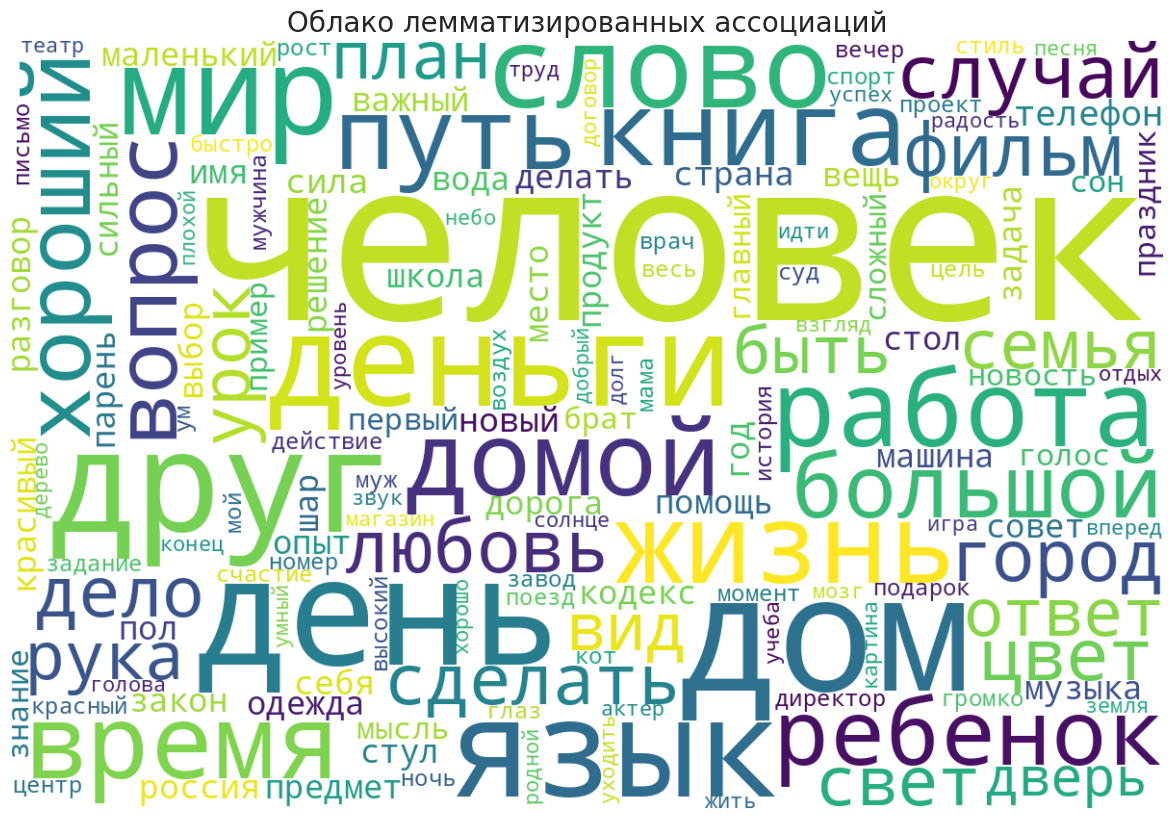

In [ ]:
top_lemmas = df_lemmas.groupby('лемма')['частота'].sum().to_dict()

wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color='white',
    colormap='viridis',
    max_words=150
).generate_from_frequencies(top_lemmas)


plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако лемматизированных ассоциаций', fontsize=20)
plt.show()


wordcloud.to_file("wordcloud_associations.png")

График, демонстрирующий распределение коэффициента разнообразия

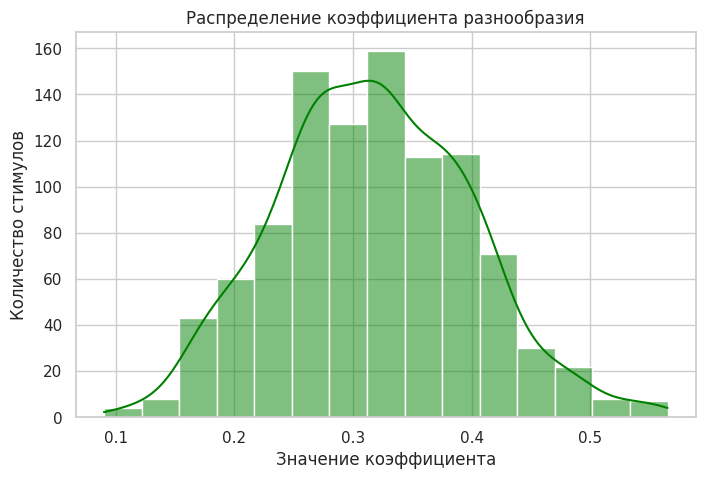

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_summary['лексическое разнообразие'], bins=15, kde=True, color='green')
plt.title('Распределение коэффициента разнообразия')
plt.xlabel('Значение коэффициента')
plt.ylabel('Количество стимулов')
plt.savefig('распределение ttr.png', dpi=300, bbox_inches='tight')
plt.show()

Построим график для 10 стимулов с самым высоким TTR и с самым низким. И сравним со средним показателем по всем словам.

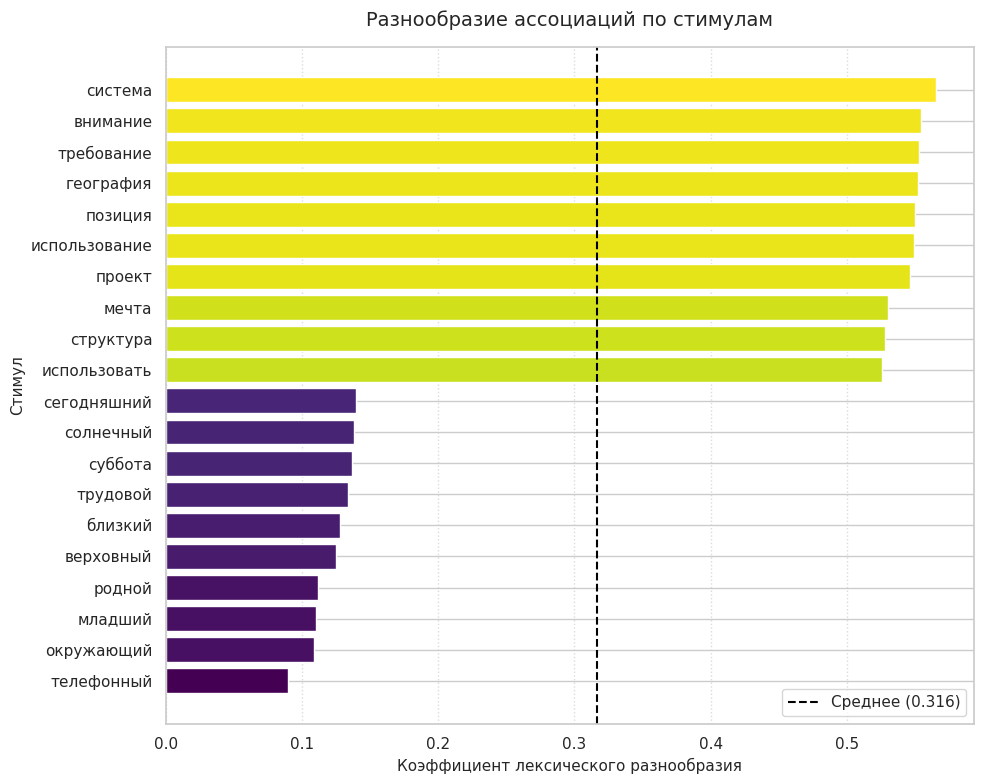

In [ ]:

top_diverse = df_summary.nlargest(10, 'лексическое разнообразие')
bottom_diverse = df_summary.nsmallest(10, 'лексическое разнообразие')
combined = pd.concat([top_diverse, bottom_diverse]).sort_values('лексическое разнообразие')


plt.figure(figsize=(10, 8))

norm = plt.Normalize(combined['лексическое разнообразие'].min(), combined['лексическое разнообразие'].max())
colors = cm.viridis(norm(combined['лексическое разнообразие']))

plt.barh(combined['стимул'], combined['лексическое разнообразие'], color=colors)

mean_val = df_summary['лексическое разнообразие'].mean()
plt.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Среднее ({mean_val:.3f})')

plt.title('Разнообразие ассоциаций по стимулам', fontsize=14, pad=15)
plt.xlabel('Коэффициент лексического разнообразия', fontsize=11)
plt.ylabel('Стимул', fontsize=11)
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.7)

plt.tight_layout()

plt.show()

## Выводы на экран ##

In [ ]:
# Топ-20 стимулов с высоким л. разнообразием
top_20 = df_summary.nlargest(20, 'лексическое разнообразие')[['стимул', 'лексическое разнообразие', 'различные ассоциации', 'всего']]

print(" ТОП-20 С ВЫСОКИМ ЛЕКСИЧЕСКИМ РАЗНООБРАЗИЕМ")
display(top_20.head(20).style.hide(axis='index'))



 ТОП-20 С ВЫСОКИМ ЛЕКСИЧЕСКИМ РАЗНООБРАЗИЕМ


стимул,лексическое разнообразие,различные ассоциации,всего
система,0.565000,282,499
внимание,0.554000,276,498
требование,0.553000,275,497
география,0.552000,274,496
позиция,0.550000,275,500
использование,0.549000,273,497
проект,0.546000,272,498
мечта,0.530000,79,149
структура,0.528000,264,500
использовать,0.526000,263,500


In [ ]:
#Топ-20 стимулов с никзим разнообразием
bottom_20 = df_summary.nsmallest(20, 'лексическое разнообразие')[['стимул', 'лексическое разнообразие', 'различные ассоциации', 'всего']]


print("ТОП-20 С НИЗКИМ ЛЕКСИЧЕСКИМ РАЗНООБРАЗИЕМ")
display(bottom_20.head(20).style.hide(axis='index'))

ТОП-20 С НИЗКИМ ЛЕКСИЧЕСКИМ РАЗНООБРАЗИЕМ


стимул,лексическое разнообразие,различные ассоциации,всего
телефонный,0.090000,45,498
окружающий,0.109000,54,495
младший,0.110000,52,474
родной,0.112000,56,498
верховный,0.125000,62,496
близкий,0.128000,64,499
трудовой,0.134000,67,500
суббота,0.137000,68,496
солнечный,0.138000,69,499
сегодняшний,0.140000,70,500


Стимулы с самым большим количеством одиночных ассоциаций и с минимальным.

In [ ]:

top_20_singles = df_summary[['стимул', 'одиночные ассоциации', 'всего']].copy()

top_20_singles = top_20_singles.sort_values('одиночные ассоциации', ascending=False).head(20)

top_20_singles.index = range(1, 21)

print("ТОП-20 СТИМУЛОВ С НАИБОЛЬШИМ КОЛИЧЕСТВОМ ОДИНОЧНЫХ АССОЦИАЦИЙ")
display(top_20_singles)

ТОП-20 СТИМУЛОВ С НАИБОЛЬШИМ КОЛИЧЕСТВОМ ОДИНОЧНЫХ АССОЦИАЦИЙ


,стимул,одиночные ассоциации,всего
1,случиться,230,995
2,удасться,229,991
3,узнавать,223,995
4,система,218,499
5,требование,209,497
6,география,207,496
7,внимание,203,498
8,использовать,203,500
9,позиция,200,500
10,проект,196,498


In [ ]:
bottom_20_singles = df_summary[['стимул', 'одиночные ассоциации', 'всего']].copy()
bottom_20_singles = bottom_20_singles.sort_values('одиночные ассоциации', ascending=True).head(20)
bottom_20_singles.index = range(1, 21)

print("ТОП-20 СТИМУЛОВ С МИНИМАЛЬНЫМ КОЛИЧЕСТВОМ ОДИНОЧНЫХ АССОЦИАЦИЙ")
display(bottom_20_singles)

ТОП-20 СТИМУЛОВ С МИНИМАЛЬНЫМ КОЛИЧЕСТВОМ ОДИНОЧНЫХ АССОЦИАЦИЙ


,стимул,одиночные ассоциации,всего
1,зима,14,149
2,телефонный,30,498
3,родной,31,498
4,радость,31,149
5,огонь,32,149
6,младший,38,474
7,звезда,38,149
8,солнечный,39,499
9,летний,40,499
10,месяц,40,488


Ассоциативные пары с самой сильной связью.

In [ ]:

top_20_nuclear_pairs = df_strongest[['стимул', 'ассоциация', 'частота', 'сила связи %']].copy()

top_20_nuclear_pairs = top_20_nuclear_pairs.sort_values('частота', ascending=False).head(20)

top_20_nuclear_pairs.index = range(1, 21)

print("ТОП-20 САМЫХ СИЛЬНЫХ АССОЦИАТИВНЫХ ПАР (ЯДРА СЕТИ)")
display(top_20_nuclear_pairs)

ТОП-20 САМЫХ СИЛЬНЫХ АССОЦИАТИВНЫХ ПАР (ЯДРА СЕТИ)


,стимул,ассоциация,частота,сила связи %
1,окружающий,мир,389,78.59
2,немецкий,язык,353,70.60
3,обратить,внимание,330,66.53
4,сегодняшний,день,329,65.80
5,английский,язык,327,65.53
6,раз,два,316,63.20
7,генеральный,директор,309,62.17
8,построить,дом,299,60.04
9,внешний,вид,295,59.24
10,французский,язык,293,58.84


In [ ]:

df_frequencies.to_csv('1_base_list.csv', index=False, encoding='utf-8-sig')
df_summary.to_csv('2_summary_stats.csv', index=False, encoding='utf-8-sig')
df_lemmas.to_csv('3_lemma_frequencies.csv', index=False, encoding='utf-8-sig')
df_strongest.to_csv('4_strongest_associations.csv', index=False, encoding='utf-8-sig')
shared_lemmas.to_csv('5_shared_lemmas.csv', index=False, encoding='utf-8-sig')
df_tfidf.to_csv('6_tf_idf.csv', index=False, encoding='utf-8-sig')


